In [6]:
!pip install xlrd


  Obtaining dependency information for xlrd from https://files.pythonhosted.org/packages/a6/0c/c2a72d51fe56e08a08acc85d13013558a2d793028ae7385448a6ccdfae64/xlrd-2.0.1-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
   ----------------------------- ---------- 71.7/96.5 kB 975.2 kB/s eta 0:00:01
   ---------------------------------------- 96.5/96.5 kB 1.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import os

file_path = r"C:\Users\vigne\OneDrive\Desktop\1744878871782DbQhJTJVkwNrXzCi.txt"
# Load the data (assuming you already did this step)
df = pd.read_csv(r"C:\Users\vigne\OneDrive\Desktop\1744878871782DbQhJTJVkwNrXzCi.txt", sep='\t')
df.head()

,Txn Date,Value Date,Description,Ref No./Cheque No.,Debit,Credit,Balance
0,21-Jan-25,21-Jan-25,TO TRANSFER-UPI/DR/502152549326/SRIKANTH/KK...,TRANSFER TO 4897692162094,20,,"19,841.43"
1,24-Jan-25,24-Jan-25,TO TRANSFER-UPI/DR/502433023242/Maddali /SB...,TRANSFER TO 4897695162091,20,,"19,821.43"
2,24-Jan-25,24-Jan-25,TO TRANSFER-UPI/DR/502433073647/V SRIDHAR/U...,TRANSFER TO 4897695162091,50,,"19,771.43"
3,25-Jan-25,25-Jan-25,TO TRANSFER-UPI/DR/502404197166/SRIKANTH/KK...,TRANSFER TO 4897695162091,20,,"19,751.43"
4,25-Jan-25,25-Jan-25,BY TRANSFER-UPI/CR/971150739533/JAKKA N/SB...,TRANSFER FROM 4897738162095,,50,"19,801.43"


In [61]:
df.columns = df.columns.str.strip()

# Replace empty strings with NaN for Debit, Credit, and Balance columns
df['Debit'] = df['Debit'].replace('', pd.NA)
df['Credit'] = df['Credit'].replace('', pd.NA)
df['Balance'] = df['Balance'].replace('', pd.NA)

df.head()

,Txn Date,Value Date,Description,Ref No./Cheque No.,Debit,Credit,Balance
0,21-Jan-25,21-Jan-25,TO TRANSFER-UPI/DR/502152549326/SRIKANTH/KK...,TRANSFER TO 4897692162094,20,,"19,841.43"
1,24-Jan-25,24-Jan-25,TO TRANSFER-UPI/DR/502433023242/Maddali /SB...,TRANSFER TO 4897695162091,20,,"19,821.43"
2,24-Jan-25,24-Jan-25,TO TRANSFER-UPI/DR/502433073647/V SRIDHAR/U...,TRANSFER TO 4897695162091,50,,"19,771.43"
3,25-Jan-25,25-Jan-25,TO TRANSFER-UPI/DR/502404197166/SRIKANTH/KK...,TRANSFER TO 4897695162091,20,,"19,751.43"
4,25-Jan-25,25-Jan-25,BY TRANSFER-UPI/CR/971150739533/JAKKA N/SB...,TRANSFER FROM 4897738162095,,50,"19,801.43"


In [62]:
# Cleaning and converting the 'Debit' column to numeric (handling errors)
df['Debit'] = df['Debit'].str.strip()  # Remove leading/trailing spaces if any
df['Debit'] = df['Debit'].replace(r'[^0-9.-]', '', regex=True)  # Remove non-numeric characters (if any)
df['Debit'] = pd.to_numeric(df['Debit'], errors='coerce')  # Convert to numeric, invalid entries become NaN
df['Debit'] = df['Debit'].fillna(0)  # Replace NaN values with 0 (or any strategy)

# Cleaning and converting the 'Credit' column to numeric (handling errors)
df['Credit'] = df['Credit'].str.strip()  # Remove leading/trailing spaces if any
df['Credit'] = df['Credit'].replace(r'[^0-9.-]', '', regex=True)  # Remove non-numeric characters (if any)
df['Credit'] = pd.to_numeric(df['Credit'], errors='coerce')  # Convert to numeric, invalid entries become NaN
df['Credit'] = df['Credit'].fillna(0)  # Replace NaN values with 0 (or any strategy)

# Cleaning and converting the 'Balance' column to numeric (handling errors)
df['Balance'] = df['Balance'].str.strip()  # Remove leading/trailing spaces if any
df['Balance'] = df['Balance'].replace(r'[^0-9.-]', '', regex=True)  # Remove non-numeric characters (if any)
df['Balance'] = pd.to_numeric(df['Balance'], errors='coerce')  # Convert to numeric, invalid entries become NaN
df['Balance'] = df['Balance'].fillna(0)  # Replace NaN values with 0 (or any strategy)

# Verify that all columns are now numeric
print(df.dtypes)


Txn Date               object
Value Date             object
Description            object
Ref No./Cheque No.     object
Debit                 float64
Credit                float64
Balance               float64
dtype: object


In [65]:
base_name = os.path.splitext(os.path.basename(file_path))[0]
csv_path = os.path.join(os.path.dirname(file_path), base_name + '.csv')

df.to_csv(csv_path, index=False)

print(f"File saved as: {csv_path}")

File saved as: C:\Users\vigne\OneDrive\Desktop\1744878871782DbQhJTJVkwNrXzCi.csv


In [66]:
# Calculate the debit_sum where Debit is less than 1000
debit_sum = df[df['Debit'] < 1000]['Debit'].sum()

# Calculate the credit_sum where Credit is less than 1000
credit_sum = df[df['Credit'] < 1000]['Credit'].sum()

# Subtract credit_sum from debit_sum
result = debit_sum - credit_sum

print(f"Debit sum (where Debit < 1000): {debit_sum}")
print(f"Credit sum (where Credit < 1000): {credit_sum}")
print(f"Result (debit_sum - credit_sum): {result}")

Debit sum (where Debit < 1000): 10494.93
Credit sum (where Credit < 1000): 1721.5
Result (debit_sum - credit_sum): 8773.43


In [ ]:
debit_sum = df[df['Debit'] <= 1]['Debit'].sum()
print(f"Debit sum for night canteen: {debit_sum}")

Debit sum for night canteen: 2544.13


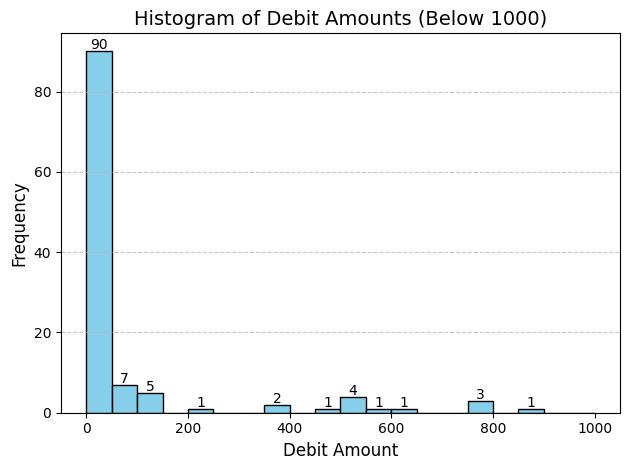

In [77]:
import matplotlib.pyplot as plt

# Filter Debit values less than 1000
debit_below_1000 = df[df['Debit'] < 1000]['Debit']

# Set up bins
bins = range(0, 1050, 50)

# Create histogram and get counts + bin edges
counts, bin_edges, patches = plt.hist(debit_below_1000, bins=bins, color='skyblue', edgecolor='black')

# Add count labels on top of each bar
for count, edge in zip(counts, bin_edges):
    if count > 0:
        plt.text(edge + 25, count + 0.5, str(int(count)), ha='center', fontsize=10)

# Customize plot
plt.title('Histogram of Debit Amounts (Below 1000)', fontsize=14)
plt.xlabel('Debit Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
